# Dataset statistics

Reproduces the **dataset-statistics** figure theme of the DeepCell Types paper:
the cell-type / tissue / modality composition of the expanded-TissueNet v10
archive, the channel (marker) panel landscape, and the marker-discriminability
diagnostics.

Panels, in order:

- **01-12** (`plot_dataset_stats.py`): cell-type abundance, composition triptych,
  per-dataset cell-type presence, tissue x cell-type prior, lineage hierarchy,
  train/val/test split sizes, modality x tissue crosstab, per-dataset cell-count
  distribution, class-imbalance Lorenz curve, cell-type-by-modality stack,
  channel co-occurrence (Jaccard), and per-channel panel statistics.
- **13-17** (`plot_channel_stats_extra.py`): modality x marker coverage,
  per-marker per-cell intensity ranges, marker x cell-type canonical-positivity
  specificity, the SVD marker-embedding t-SNE, and the single-channel
  intensity AUC heatmap.

> **Provenance / execution note.** Panels 01-13 and 15 are computed live from
> the **expanded-TissueNet zarr archive** (`paths.EXPANDED_TISSUENET_ZARR`;
> public users set `DATA_DIR` to their downloaded copy). The per-cell metadata
> scan walks one `zarr.json` triple per FOV across the split's ~2.1k FOVs, so
> the shared-scan cell below is **slow** (a few minutes). Panels 14 and 17 read
> the cached per-cell intensity table (`channel_intensity_stats.npz`) so they
> need no archive rescan; panel 16 reads the SVD marker embedding
> (`svd_512.npz`). The per-cell scan uses the
> `splits/fov_split_v10_valsubset.json` split (train + val + held-out),
> matching the source scripts' default.

All figures are styled to the **Science Advances 2026** figure spec via
`dct_figures.style`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from dct_figures import paths, style, colors
style.apply_style()

In [2]:
import json, yaml
from collections import Counter, defaultdict
from pathlib import Path
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from dct_figures.style import (
    PAL, LINEAGE_COLORS, LINEAGE_ORDER, STACKED_COLORS,
    CMAP_BLUES, CMAP_WARM, COL_1, COL_1_5, COL_2, MAX_HEIGHT,
    BAR_WIDTH, BAR_WIDTH_GROUP, style_ax, use_log_count_axis,
    is_narrow_figure,
)
style_ax = style.style_ax
use_log_count_axis = style.use_log_count_axis
is_narrow_figure = style.is_narrow_figure

## Dataset overview (quick counts)

A fast, archive-wide orientation built from the small git-tracked count CSVs
(`data/count_by_type.csv`, `count_by_tissue.csv`,
`count_by_imaging_modality.csv`) — aggregate cell counts over the *full* v10
archive. These mirror the original published Figure-1 bar charts. (The
zarr-computed panels below are restricted to the split FOVs and so report
smaller per-split totals.)

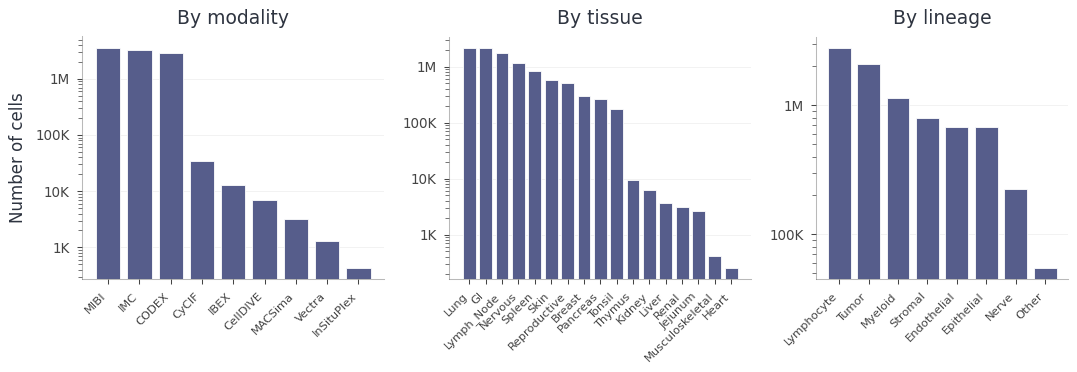

full-archive totals  cells=8,442,541  types=46  tissues=17  modalities=9


In [3]:
lineage_yaml = yaml.safe_load(open(paths.DATA_ROOT / 'lineage_mapping.yaml'))

ct = pd.read_csv(paths.DATA_ROOT / 'count_by_type.csv', header=None)
ct.columns = ['cell_type', 'n']
ct['lineage'] = ct['cell_type'].map(lineage_yaml).fillna('Other')
lin = ct.groupby('lineage')['n'].sum().sort_values(ascending=False)
tis = pd.read_csv(paths.DATA_ROOT / 'count_by_tissue.csv', header=None,
                  index_col=0)[1].sort_values(ascending=False)
mod = pd.read_csv(paths.DATA_ROOT / 'count_by_imaging_modality.csv', header=None,
                  index_col=0)[1].sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(COL_2, 2.6),
                         gridspec_kw={'width_ratios': [1.2, 1.2, 1.0]})
for ax, (data, title) in zip(axes, [(mod, 'By modality'),
                                     (tis, 'By tissue'),
                                     (lin, 'By lineage')]):
    bars = ax.bar(range(len(data)), data.values, color=PAL['theme'],
                  width=BAR_WIDTH, edgecolor='white')
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.index, rotation=45, ha='right', fontsize=5.5)
    ax.set_title(title)
    use_log_count_axis(ax, 'y')
    style_ax(ax, 'y')
axes[0].set_ylabel('Number of cells')
fig.tight_layout()
plt.show()
print(f"full-archive totals  cells={ct['n'].sum():,}  "
      f"types={len(ct)}  tissues={len(tis)}  modalities={len(mod)}")

## Shared archive scan (per-FOV metadata)

The 01-12 panels all consume the same per-FOV metadata records (tissue,
modality, channel panel, per-cell-type counts) collected by walking the zarr
archive's `zarr.json` files for every FOV in the split. We build a torch-free
`ArchiveConfig` shim (mirroring the `dct_figures` pattern used by the sibling
notebooks — no `deepcell_types` / `torch` import) that exposes exactly the
fields the vendored plotting functions read: `zarr_path`, `ct2idx`,
`lineage_mapping`, `tissue_celltype_mapping`, `dataset_keys`, and a lazy
`marker_positivity_labels` dict. The scan is computed **once** here and reused
across every downstream panel (DRY).

In [4]:
import zarr

SPLIT_FILE = paths.SPLITS / 'fov_split_v10_valsubset.json'
ZARR_PATH = paths.need(paths.EXPANDED_TISSUENET_ZARR)


class ArchiveConfig:
    '''Torch-free stand-in for deepcell_types TissueNetConfig.

    Provides only the fields the vendored data-stats plotting code reads,
    derived directly from the expanded-TissueNet zarr archive (root attrs +
    per-FOV zarr.json files). No torch / deepcell_types import.
    '''

    def __init__(self, zarr_path):
        self.zarr_path = pathlib.Path(zarr_path)
        self._zf = zarr.open_group(str(self.zarr_path), mode='r')
        attrs = dict(self._zf.attrs)
        # ct2idx from the archive cell_type_mapping (51 standardized types).
        self.ct2idx = {ct: idx for ct, idx in attrs.get('cell_type_mapping', {}).items()}
        self.lineage_mapping = dict(attrs.get('lineage_mapping', {}))
        self.color_mapping = dict(attrs.get('color_mapping', {}))
        self._dataset_keys = None
        self._tissue_ct = None
        self._mp_cache = {}

    @property
    def dataset_keys(self):
        if self._dataset_keys is None:
            root = str(self.zarr_path)
            self._dataset_keys = sorted(
                p.parent.parent.relative_to(root).as_posix()
                for p in self.zarr_path.glob('**/preprocessed/zarr.json')
            )
        return self._dataset_keys

    @property
    def tissue_celltype_mapping(self):
        '''tissue -> sorted list of annotated cell types (in ct2idx).'''
        if self._tissue_ct is None:
            tmap = defaultdict(set)
            zdir = str(self.zarr_path)
            for key in self.dataset_keys:
                try:
                    with open(f'{zdir}/{key}/zarr.json') as f:
                        ds_attrs = json.load(f).get('attributes', {})
                    tissue = ds_attrs.get('tissue', 'unknown').lower().strip()
                    with open(f'{zdir}/{key}/cell_types/annotations/zarr.json') as f:
                        ann = json.load(f).get('attributes', {})
                except (FileNotFoundError, OSError):
                    continue
                for src_key in ('standardized_source', 'caitlinb'):
                    src = ann.get(src_key, {})
                    if src:
                        tmap[tissue].update(
                            ct for ct in src if ct in self.ct2idx)
                        break
            self._tissue_ct = {k: sorted(v) for k, v in tmap.items() if v}
        return self._tissue_ct

    @property
    def marker_positivity_labels(self):
        '''Lazy dict: dataset_key -> MP DataFrame (cell types x markers).'''
        return _MPDict(self)

    def _load_mp(self, key):
        if key in self._mp_cache:
            return self._mp_cache[key]
        df = None
        try:
            ds = self._zf[key]
            if 'marker_positivity' in ds:
                mp = ds['marker_positivity']
                markers = list(mp.attrs.get('markers', []))
                cts = list(mp.attrs.get('cell_types', []))
                matrix = list(mp.attrs.get('positivity_matrix', []))
                if markers and cts and matrix:
                    df = pd.DataFrame(matrix, index=cts, columns=markers)
        except (KeyError, ValueError):
            df = None
        self._mp_cache[key] = df
        return df

    def _mp_keys(self):
        zdir = str(self.zarr_path)
        return [k for k in self.dataset_keys
                if Path(f'{zdir}/{k}/marker_positivity/zarr.json').exists()]


class _MPDict:
    '''Dict-like wrapper over ArchiveConfig MP DataFrames (lazy).'''

    def __init__(self, config):
        self._config = config
        self._keys = config._mp_keys()

    def keys(self):
        return list(self._keys)

    def __iter__(self):
        return iter(self._keys)

    def __contains__(self, key):
        return key in self._keys

    def __getitem__(self, key):
        return self._config._load_mp(key)


def collect_dataset_stats(config, split_data, min_channels=3):
    '''Vendored from analysis/plot_dataset_stats.py (torch-free).

    Walks the archive zarr.json files for each FOV in the split and returns
    per-FOV records (tissue, modality, channels, per-cell-type counts, split).
    '''
    zarr_dir = str(config.zarr_path)
    test_split = split_data.get('test') or split_data.get('heldout') or {}
    split_keys = (set(split_data.get('train', {}))
                  | set(split_data.get('val', {}))
                  | set(test_split))
    records = []
    for key in config.dataset_keys:
        if key not in split_keys:
            continue
        ds_json = Path(zarr_dir) / key / 'zarr.json'
        pp_json = Path(zarr_dir) / key / 'preprocessed' / 'zarr.json'
        ann_json = Path(zarr_dir) / key / 'cell_types' / 'annotations' / 'zarr.json'
        try:
            with open(ds_json) as f:
                ds_attrs = json.load(f).get('attributes', {})
        except (FileNotFoundError, OSError):
            continue
        tissue = ds_attrs.get('tissue', 'unknown').lower().strip()
        modality = ds_attrs.get('modality', 'unknown').upper()
        try:
            with open(pp_json) as f:
                pp_attrs = json.load(f).get('attributes', {})
        except (FileNotFoundError, OSError):
            pp_attrs = {}
        channels = pp_attrs.get('channel_names', [])
        if len(channels) < min_channels:
            continue
        ct_counts = {}
        try:
            with open(ann_json) as f:
                ann_attrs = json.load(f).get('attributes', {})
            for source_key in ('standardized_source', 'caitlinb'):
                source = ann_attrs.get(source_key, {})
                if source:
                    for ct_name, cells in source.items():
                        if ct_name is None or ct_name == 'null':
                            continue
                        if ct_name not in config.ct2idx:
                            continue
                        if isinstance(cells, (list, dict)):
                            n = len(cells)
                        elif isinstance(cells, (int, float)):
                            n = int(cells)
                        else:
                            n = 1
                        ct_counts[ct_name] = ct_counts.get(ct_name, 0) + n
                    break
        except (FileNotFoundError, OSError):
            continue
        if not ct_counts:
            continue
        if key in split_data.get('train', {}):
            split = 'train'
        elif key in split_data.get('val', {}):
            split = 'val'
        else:
            split = 'test'
        records.append({
            'key': key, 'tissue': tissue, 'modality': modality,
            'channels': channels, 'n_channels': len(channels),
            'ct_counts': ct_counts, 'n_cells': sum(ct_counts.values()),
            'split': split,
        })
    return records


def _get_lineage(ct, lineage_map):
    return lineage_map.get(ct, 'Other')


def _lineage_legend(lineage_map, cts, ax, **kwargs):
    present = sorted(set(_get_lineage(ct, lineage_map) for ct in cts))
    ordered = [l for l in LINEAGE_ORDER if l in present]
    handles = [Patch(facecolor=LINEAGE_COLORS.get(l, '#A0A8B4'), label=l)
               for l in ordered]
    ax.legend(handles=handles, framealpha=0.95, **kwargs)


config = ArchiveConfig(ZARR_PATH)
split_data = json.load(open(SPLIT_FILE))
print(f'archive: {ZARR_PATH}')
print(f'split:   {SPLIT_FILE.name}')
print('scanning per-FOV metadata (slow; ~2.1k FOVs)...')
records = collect_dataset_stats(config, split_data, min_channels=3)
total_cells = sum(r['n_cells'] for r in records)
print(f'  {len(records)} FOVs, {total_cells:,} labeled cells after split + '
      f'min_channels filter')

archive: /data/xwang3/expanded-tissuenet.zarr
split:   fov_split_v10_valsubset.json
scanning per-FOV metadata (slow; ~2.1k FOVs)...


  2153 FOVs, 8,719,781 labeled cells after split + min_channels filter


## 01_celltype_abundance

_Caption:_ Cell-type abundance — global frequency across the v10 archive.

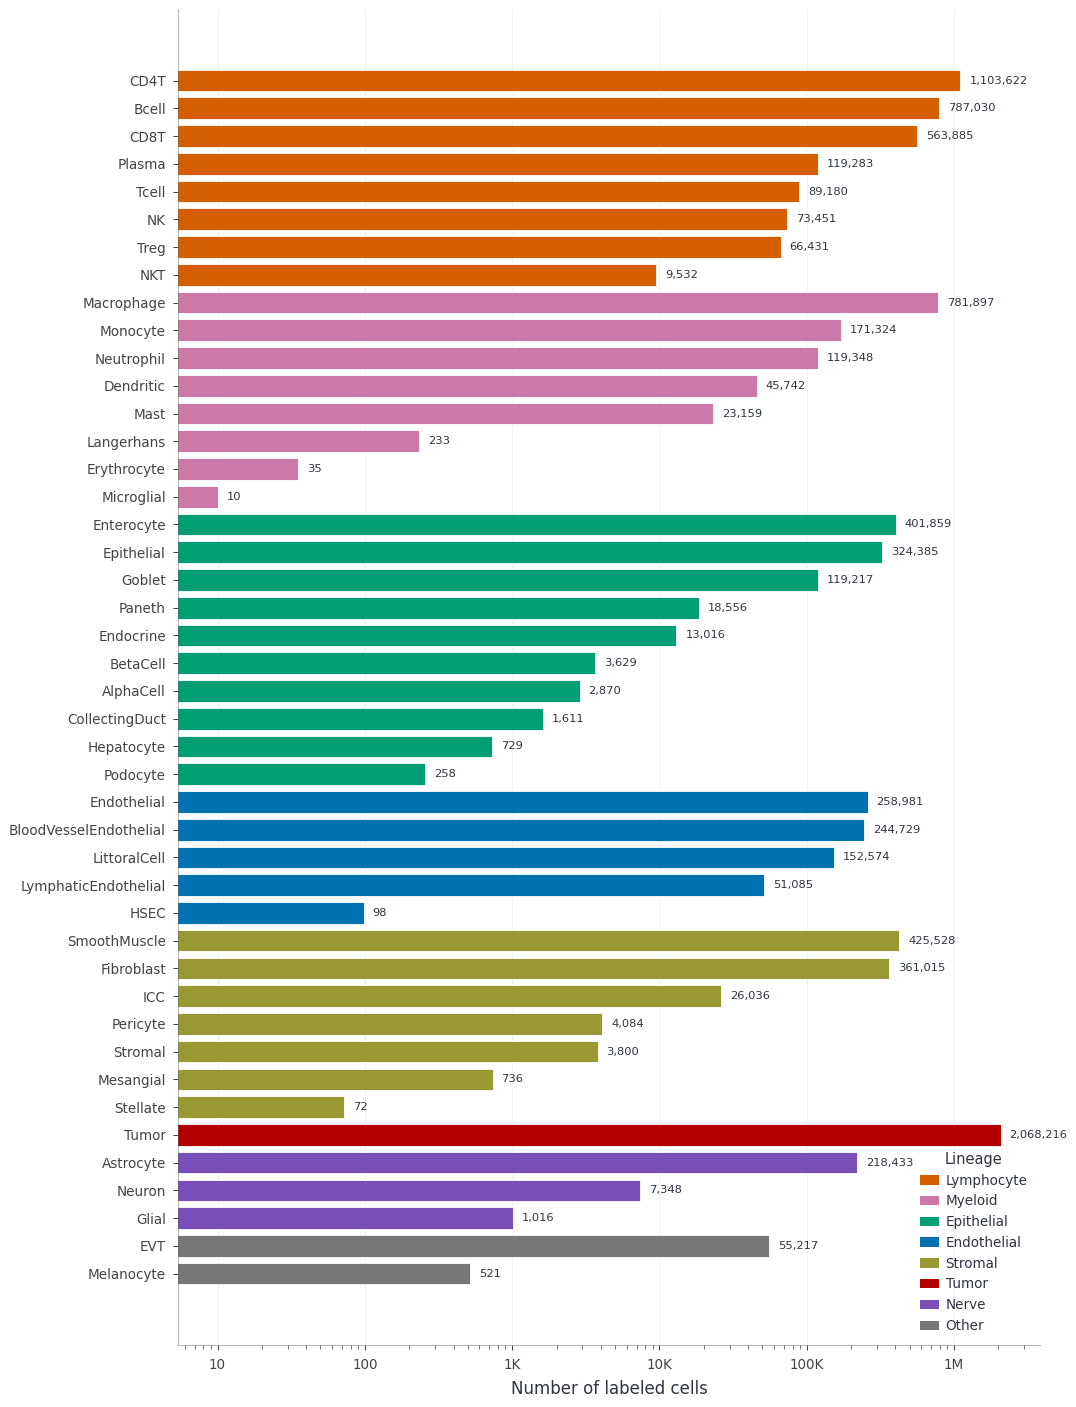

44 types, 8,719,781 cells


In [5]:
ct_total = Counter()
for r in records:
    ct_total.update(r['ct_counts'])
lineage_map = config.lineage_mapping

by_lineage = defaultdict(list)
for ctn in ct_total:
    by_lineage[_get_lineage(ctn, lineage_map)].append(ctn)
display_order = []
for lin_ in LINEAGE_ORDER:
    display_order.extend(sorted(by_lineage.get(lin_, []), key=lambda c: -ct_total[c]))
leftover = sorted((c for c in ct_total if c not in display_order),
                  key=lambda c: -ct_total[c])
display_order.extend(leftover)
sorted_cts = list(reversed(display_order))
counts = [ct_total[c] for c in sorted_cts]
cols = [LINEAGE_COLORS.get(_get_lineage(c, lineage_map), '#A0A8B4') for c in sorted_cts]

fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(6.5, len(sorted_cts) * 0.22))))
bars = ax.barh(range(len(sorted_cts)), counts, color=cols, height=BAR_WIDTH,
               edgecolor='white')
ax.set_yticks(range(len(sorted_cts)))
ax.set_yticklabels(sorted_cts, fontsize=6.5)
ax.set_xlabel('Number of labeled cells')
use_log_count_axis(ax, 'x')
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=5.5, color=PAL['dark'])
_lineage_legend(lineage_map, sorted_cts, ax, loc='lower right', title='Lineage')
style_ax(ax, grid_axis='x')
fig.tight_layout()
plt.show()
print(f'{len(sorted_cts)} types, {sum(counts):,} cells')

## 02_composition_panels

_Caption:_ Modality, tissue, and lineage composition triptych.

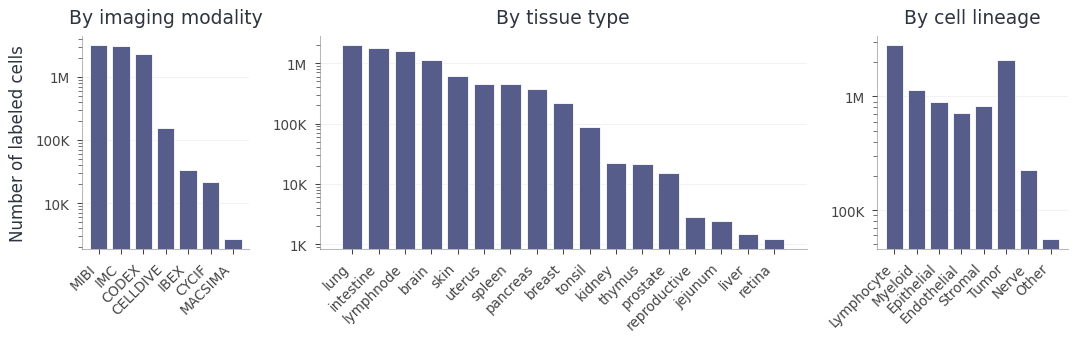

7 modalities, 17 tissues, 8 lineages


In [6]:
modality_counts, tissue_counts, lineage_counts = Counter(), Counter(), Counter()
for r in records:
    for ctn, n in r['ct_counts'].items():
        modality_counts[r['modality']] += n
        tissue_counts[r['tissue']] += n
        lineage_counts[_get_lineage(ctn, lineage_map)] += n

lineages_in = [l for l in LINEAGE_ORDER if l in lineage_counts]
n_mods = max(len(modality_counts), 1)
n_tissues = max(len(tissue_counts), 1)
n_lineages = max(len(lineages_in), 1)
fig, axes = plt.subplots(1, 3, figsize=(COL_2, 2.4),
                         gridspec_kw={'width_ratios': [n_mods, n_tissues * 1.20, n_lineages]})
for ax, (cnt, title) in zip(
        axes, [(modality_counts, 'By imaging modality'),
               (tissue_counts, 'By tissue type'),
               (None, 'By cell lineage')]):
    if title == 'By cell lineage':
        cats = lineages_in
        vals = [lineage_counts[l] for l in cats]
    else:
        cats = sorted(cnt, key=lambda x: -cnt[x])
        vals = [cnt[c] for c in cats]
    ax.bar(range(len(cats)), vals, color=PAL['theme'], width=BAR_WIDTH,
           edgecolor='white')
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, rotation=45, ha='right')
    ax.set_title(title)
    use_log_count_axis(ax, 'y')
    style_ax(ax, 'y')
axes[0].set_ylabel('Number of labeled cells')
fig.tight_layout()
plt.show()
print(f'{n_mods} modalities, {n_tissues} tissues, {n_lineages} lineages')

## 03_celltype_presence_heatmap

_Caption:_ Cell-type presence per dataset (binary heatmap).

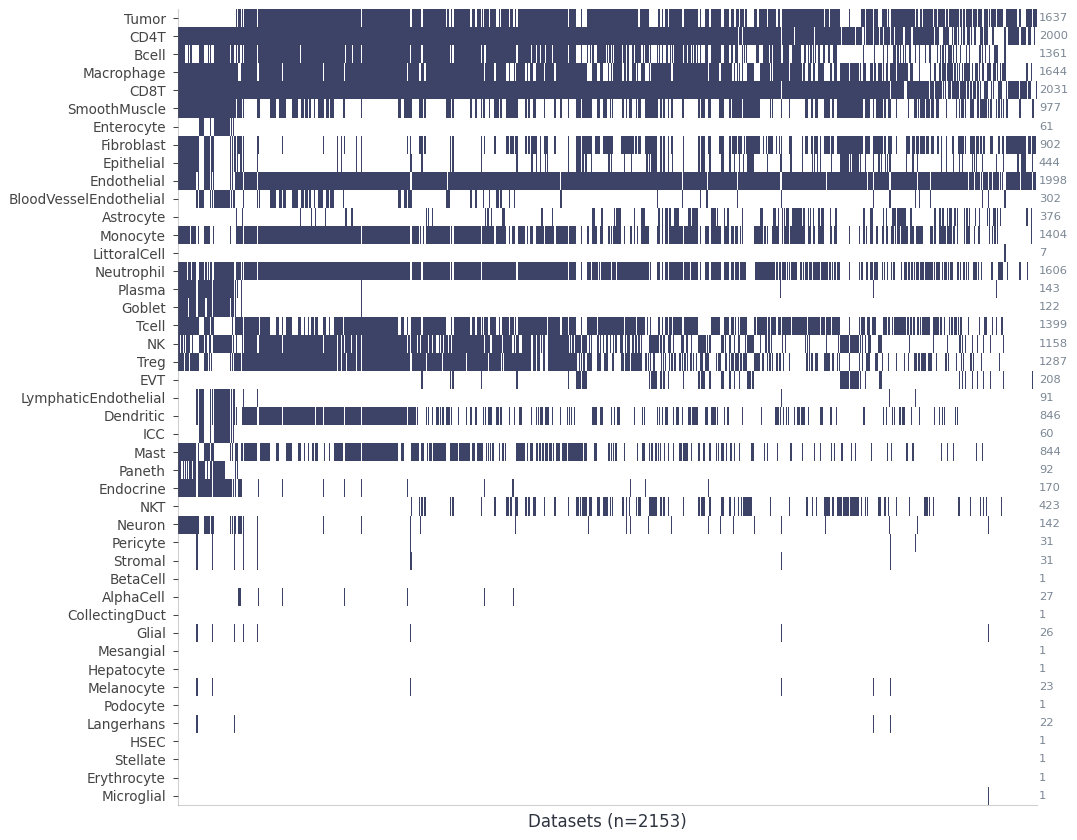

44 x 2153


In [7]:
present_cts = sorted(ct_total.keys(), key=lambda x: -ct_total[x])
matrix = np.zeros((len(present_cts), len(records)), dtype=np.float32)
for j, r in enumerate(records):
    for ctn in r['ct_counts']:
        if ctn in present_cts:
            matrix[present_cts.index(ctn), j] = 1.0
matrix = matrix[:, np.argsort(-matrix.sum(axis=0))]

fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(4.0, len(present_cts) * 0.13))))
ax.imshow(matrix, aspect='auto', cmap=CMAP_BLUES, interpolation='nearest')
ax.set_yticks(range(len(present_cts)))
ax.set_yticklabels(present_cts, fontsize=6.5)
ax.set_xlabel(f'Datasets (n={len(records)})')
ax.set_xticks([])
for i, ctn in enumerate(present_cts):
    ax.text(len(records) + 3, i, str(int(matrix[i].sum())), va='center',
            fontsize=5.5, color=PAL['gray'])
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_alpha(0.3)
fig.tight_layout()
plt.show()
print(f'{len(present_cts)} x {len(records)}')

## 04_tissue_celltype_heatmap

_Caption:_ Tissue x cell-type empirical prior heatmap.

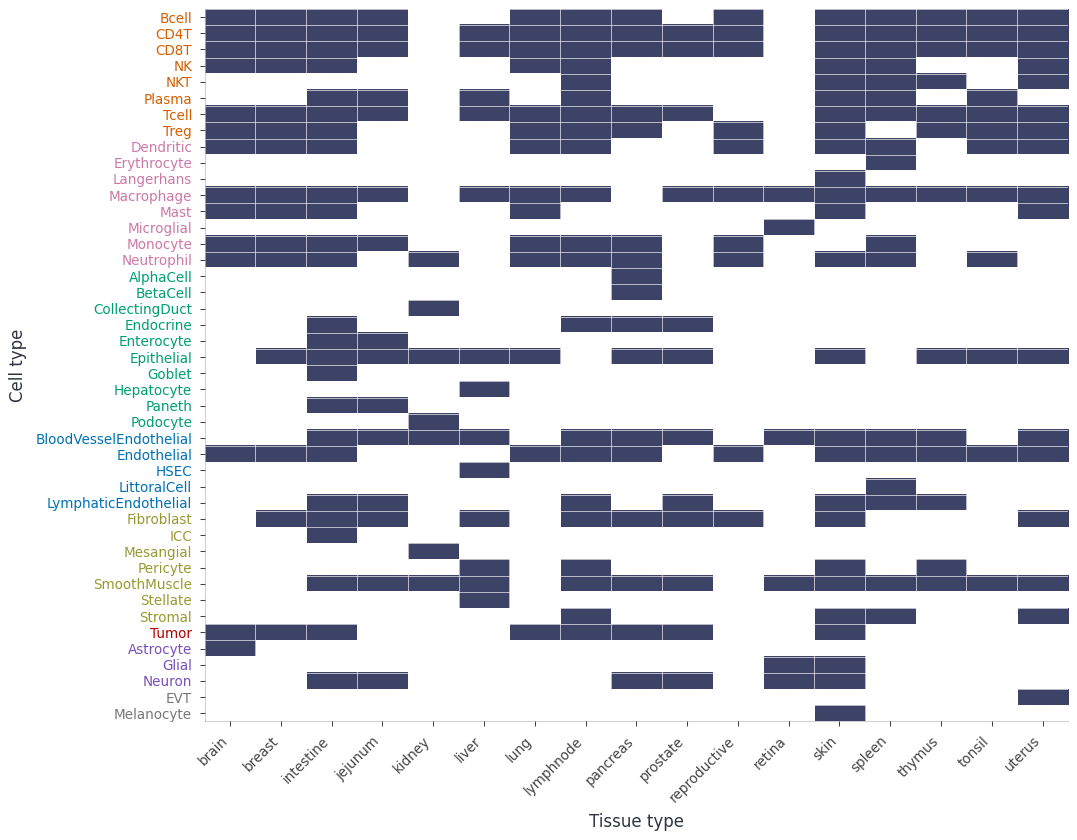

44 x 17


In [8]:
tissue_ct = config.tissue_celltype_mapping
tissues_in_data, cts_in_data = set(), set()
for r in records:
    tissues_in_data.add(r['tissue'])
    cts_in_data.update(r['ct_counts'])
tissues = sorted(t for t in tissue_ct if t in tissues_in_data and len(tissue_ct[t]) > 0)
cts = sorted(c for c in config.ct2idx if c in cts_in_data)
cts.sort(key=lambda c: (LINEAGE_ORDER.index(_get_lineage(c, lineage_map))
                        if _get_lineage(c, lineage_map) in LINEAGE_ORDER else 99, c))
mat4 = np.zeros((len(cts), len(tissues)), dtype=np.float32)
for j, tissue in enumerate(tissues):
    valid = set(tissue_ct.get(tissue, []))
    for i, ctn in enumerate(cts):
        if ctn in valid:
            mat4[i, j] = 1.0

fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(4.5, len(cts) * 0.13))))
ax.imshow(mat4, aspect='auto', cmap=CMAP_BLUES, interpolation='nearest')
ax.set_yticks(range(len(cts)))
ax.set_yticklabels(cts, fontsize=6.5)
for i, ctn in enumerate(cts):
    ax.get_yticklabels()[i].set_color(
        LINEAGE_COLORS.get(_get_lineage(ctn, lineage_map), PAL['dark']))
ax.set_xticks(range(len(tissues)))
ax.set_xticklabels(tissues, rotation=45, ha='right', fontsize=6.5)
ax.set_xlabel('Tissue type'); ax.set_ylabel('Cell type')
ax.set_xticks(np.arange(-0.5, len(tissues), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(cts), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.3)
ax.tick_params(which='minor', size=0)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_alpha(0.3)
fig.tight_layout()
plt.show()
print(f'{len(cts)} x {len(tissues)}')

## 05_celltype_hierarchy

_Caption:_ Cell-type lineage hierarchy used for hierarchical-collapsed eval.

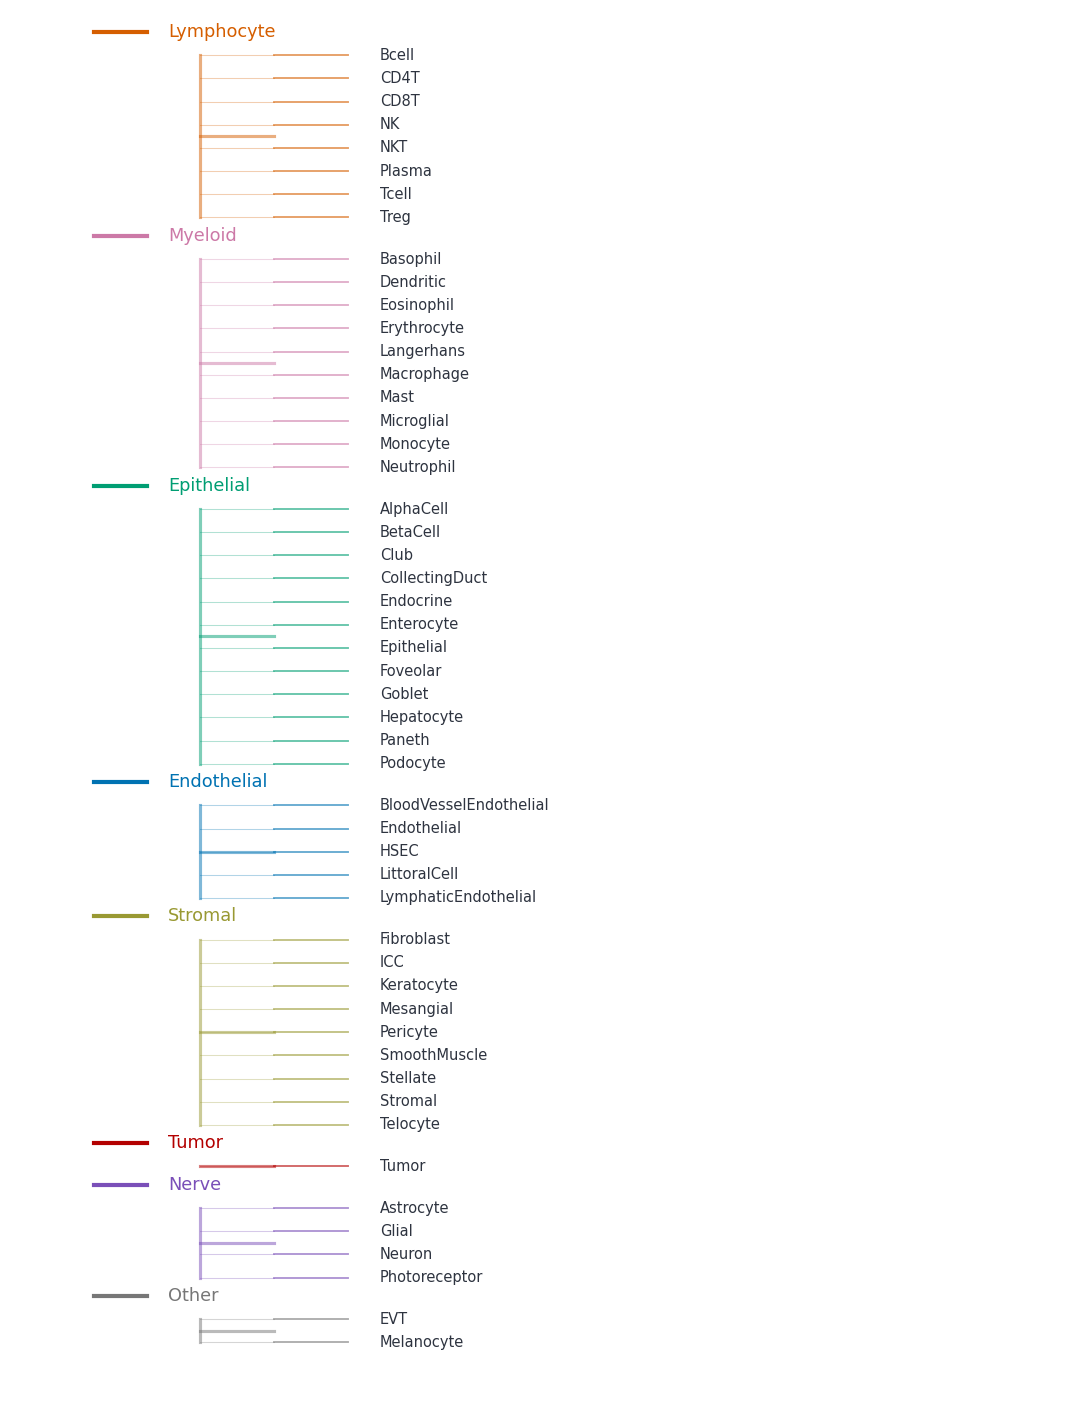

8 lineages, 51 types


In [9]:
groups = defaultdict(list)
for ctn in sorted(config.ct2idx):
    groups[_get_lineage(ctn, lineage_map)].append(ctn)
lineages = [l for l in LINEAGE_ORDER if l in groups]
total_cts = sum(len(groups[l]) for l in lineages)

fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(6.0, total_cts * 0.25 + 1.0))))
ax.set_xlim(0, 10); ax.set_ylim(-1, total_cts + len(lineages)); ax.axis('off')
y = total_cts + len(lineages) - 1
for lin_ in lineages:
    color = LINEAGE_COLORS.get(lin_, '#A0A8B4')
    cts_l = groups[lin_]
    ax.text(1.5, y, lin_, fontsize=8.5, color=color, va='center')
    ax.plot([0.8, 1.3], [y, y], color=color, linewidth=2.0)
    top_y = y
    for ctn in cts_l:
        y -= 1
        ax.text(3.5, y, ctn, fontsize=7.0, va='center', color=PAL['dark'])
        ax.plot([2.5, 3.2], [y, y], color=color, linewidth=0.9, alpha=0.6)
    if cts_l:
        bottom_y = y
        mid_y = (top_y - 1 + bottom_y) / 2
        ax.plot([1.8, 1.8], [top_y - 1, bottom_y], color=color, linewidth=1.5, alpha=0.5)
        ax.plot([1.8, 2.5], [mid_y, mid_y], color=color, linewidth=1.5, alpha=0.5)
        for k in range(len(cts_l)):
            cy = top_y - 1 - k
            ax.plot([1.8, 2.5], [cy, cy], color=color, linewidth=0.5, alpha=0.3)
    y -= 0.8
fig.tight_layout()
plt.show()
print(f'{len(lineages)} lineages, {total_cts} types')

## 06_train_val_test_comparison

_Caption:_ Train / val / test per-modality split sizes.

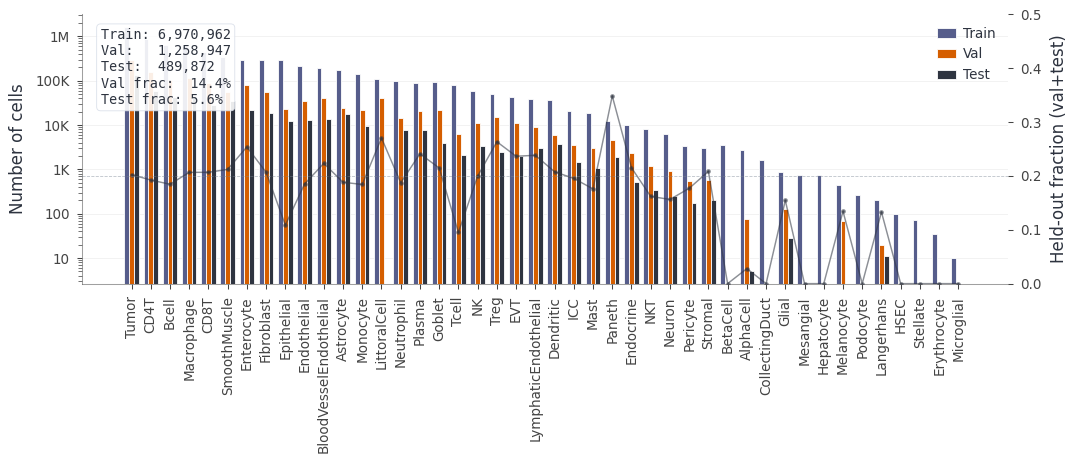

train=6,970,962, val=1,258,947, test=489,872


In [10]:
train_counts, val_counts, test_counts = Counter(), Counter(), Counter()
bucket = {'train': train_counts, 'val': val_counts, 'test': test_counts}
for r in records:
    bucket[r['split']].update(r['ct_counts'])
has_test = sum(test_counts.values()) > 0
all_cts = sorted(set(train_counts) | set(val_counts) | set(test_counts),
                 key=lambda x: -(train_counts[x] + val_counts[x] + test_counts[x]))
x = np.arange(len(all_cts))

fig, ax = plt.subplots(figsize=(COL_2, 3.2))
if has_test:
    w = BAR_WIDTH_GROUP * 0.66
    for off, (label, cnt, color) in zip(
            (-w, 0.0, w),
            [('Train', train_counts, PAL['theme']), ('Val', val_counts, PAL['red']),
             ('Test', test_counts, PAL['dark'])]):
        ax.bar(x + off, [cnt[c] for c in all_cts], w, label=label, color=color,
               edgecolor='white')
else:
    w = BAR_WIDTH_GROUP
    ax.bar(x - w / 2, [train_counts[c] for c in all_cts], w, label='Train',
           color=PAL['theme'], edgecolor='white')
    ax.bar(x + w / 2, [val_counts[c] for c in all_cts], w, label='Val',
           color=PAL['red'], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(all_cts, rotation=90)
ax.set_ylabel('Number of cells')
use_log_count_axis(ax, 'y')
ax.legend(loc='upper right')
style_ax(ax, 'y')
ax2 = ax.twinx()
if has_test:
    ratios = [(val_counts[c] + test_counts[c])
              / max(train_counts[c] + val_counts[c] + test_counts[c], 1) for c in all_cts]
    ax2.set_ylabel('Held-out fraction (val+test)')
else:
    ratios = [val_counts[c] / max(train_counts[c] + val_counts[c], 1) for c in all_cts]
    ax2.set_ylabel('Val fraction')
ax2.plot(x, ratios, color=PAL['dark'], linewidth=0.7, alpha=0.55, marker='.', markersize=2.5)
ax2.axhline(0.2, color=PAL['gray'], linestyle='--', linewidth=0.4, alpha=0.5)
ax2.set_ylim(0, 0.5)
for sp in ('top',):
    ax2.spines[sp].set_visible(False)
for sp in ('left', 'right', 'bottom'):
    ax2.spines[sp].set_alpha(0.3)
n_train, n_val, n_test = (sum(train_counts.values()), sum(val_counts.values()),
                          sum(test_counts.values()))
total = max(n_train + n_val + n_test, 1)
info = (f'Train: {n_train:,}\nVal:   {n_val:,}\nTest:  {n_test:,}\n'
        f'Val frac:  {n_val / total:.1%}\nTest frac: {n_test / total:.1%}') if has_test \
    else f'Train: {n_train:,}\nVal:   {n_val:,}\nVal frac: {n_val / total:.1%}'
ax.text(0.02, 0.95, info, transform=ax.transAxes, ha='left', va='top', fontsize=6.5,
        color=PAL['dark'], family='monospace',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=PAL['light_gray'], linewidth=0.4, alpha=0.9))
fig.tight_layout()
plt.show()
print(f'train={n_train:,}, val={n_val:,}, test={n_test:,}')

## 07_modality_tissue_crosstab

_Caption:_ Modality x tissue crosstab of dataset counts.

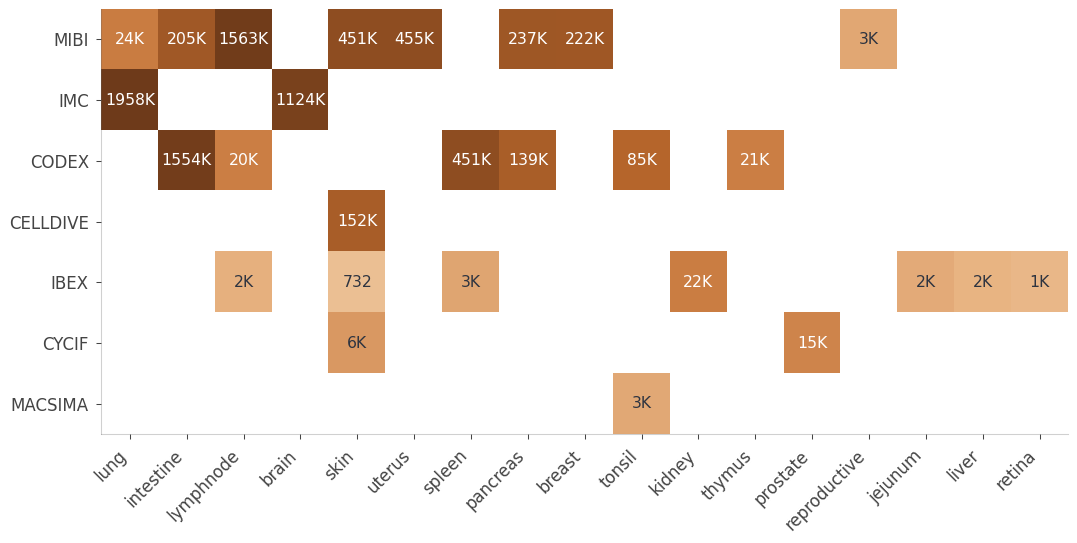

7 x 17


In [11]:
crosstab = defaultdict(Counter)
for r in records:
    crosstab[r['modality']][r['tissue']] += r['n_cells']
modalities = sorted(crosstab, key=lambda m: -sum(crosstab[m].values()))
tissues7 = sorted(set(t for c in crosstab.values() for t in c),
                  key=lambda t: -sum(crosstab[m][t] for m in modalities))
mat7 = np.zeros((len(modalities), len(tissues7)))
for i, mod_ in enumerate(modalities):
    for j, tis_ in enumerate(tissues7):
        mat7[i, j] = crosstab[mod_][tis_]

fig, ax = plt.subplots(figsize=(COL_2, max(3.0, len(modalities) * 0.42 + 0.8)))
fmt_cells = lambda v: f'{v / 1e3:.0f}K' if v >= 1e3 else (str(int(v)) if v > 0 else '')
ax.imshow(np.log1p(mat7), aspect='auto', cmap=CMAP_WARM, interpolation='nearest')
ax.set_xticks(range(len(tissues7)))
ax.set_xticklabels(tissues7, rotation=45, ha='right', fontsize=8.0)
ax.set_yticks(range(len(modalities)))
ax.set_yticklabels(modalities, fontsize=8.0)
for i in range(len(modalities)):
    for j in range(len(tissues7)):
        val = mat7[i, j]
        if val > 0:
            color = 'white' if np.log1p(val) > np.log1p(mat7.max()) * 0.6 else PAL['dark']
            ax.text(j, i, fmt_cells(val), ha='center', va='center', fontsize=7.5, color=color)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_alpha(0.3)
fig.tight_layout()
plt.show()
print(f'{len(modalities)} x {len(tissues7)}')

## 08_dataset_cell_distribution

_Caption:_ Per-dataset cell-count distribution.

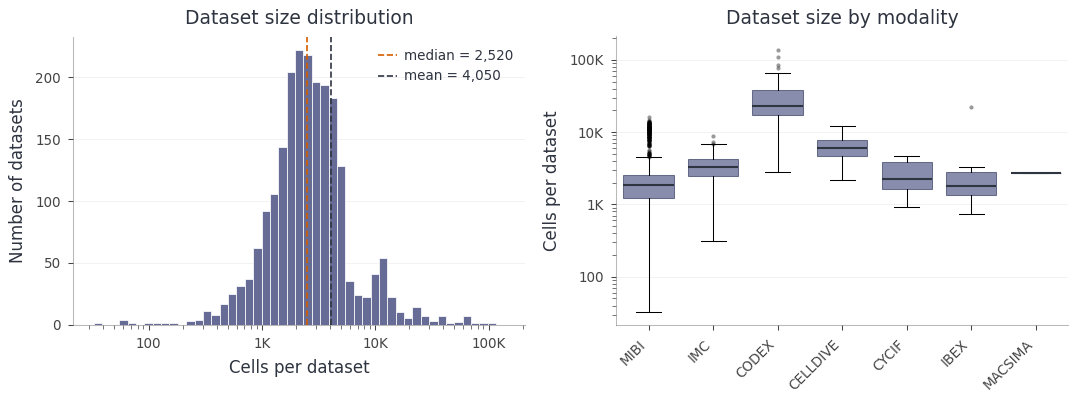

2153 datasets, median=2,520, mean=4,050


In [12]:
n_cells = np.array([r['n_cells'] for r in records])
modalities8 = [r['modality'] for r in records]
unique_mods = sorted(set(modalities8), key=lambda m: -sum(1 for x in modalities8 if x == m))

fig, axes = plt.subplots(1, 2, figsize=(COL_2, 2.8))
ax = axes[0]
log_bins = np.logspace(np.log10(max(n_cells.min(), 1)), np.log10(n_cells.max()), 50)
ax.hist(n_cells, bins=log_bins, color=PAL['theme'], edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(np.median(n_cells), color=PAL['red'], linestyle='--', linewidth=0.8,
           label=f'median = {np.median(n_cells):,.0f}')
ax.axvline(np.mean(n_cells), color=PAL['dark'], linestyle='--', linewidth=0.8,
           label=f'mean = {np.mean(n_cells):,.0f}')
ax.set_xlabel('Cells per dataset'); ax.set_ylabel('Number of datasets')
ax.set_title('Dataset size distribution')
use_log_count_axis(ax, 'x'); ax.legend(loc='upper right'); style_ax(ax, 'y')
ax = axes[1]
mod_data = [[r['n_cells'] for r in records if r['modality'] == m] for m in unique_mods]
bp = ax.boxplot(mod_data, tick_labels=unique_mods, patch_artist=True, showfliers=True,
                widths=BAR_WIDTH, flierprops=dict(marker='.', markersize=2, alpha=0.4))
for patch in bp['boxes']:
    patch.set_facecolor(PAL['theme']); patch.set_alpha(0.7)
    patch.set_edgecolor(PAL['theme_dark']); patch.set_linewidth(0.5)
for m_ in bp['medians']:
    m_.set_color(PAL['dark']); m_.set_linewidth(1.0)
for w_ in bp['whiskers']:
    w_.set_linewidth(0.5)
for cap in bp['caps']:
    cap.set_linewidth(0.5)
ax.set_ylabel('Cells per dataset'); ax.set_title('Dataset size by modality')
ax.set_xticklabels(unique_mods, rotation=45, ha='right')
use_log_count_axis(ax, 'y'); style_ax(ax, 'y')
fig.tight_layout()
plt.show()
print(f'{len(records)} datasets, median={np.median(n_cells):,.0f}, mean={np.mean(n_cells):,.0f}')

## 09_class_imbalance

_Caption:_ Class imbalance curve + Lorenz ranking across the v10 archive.

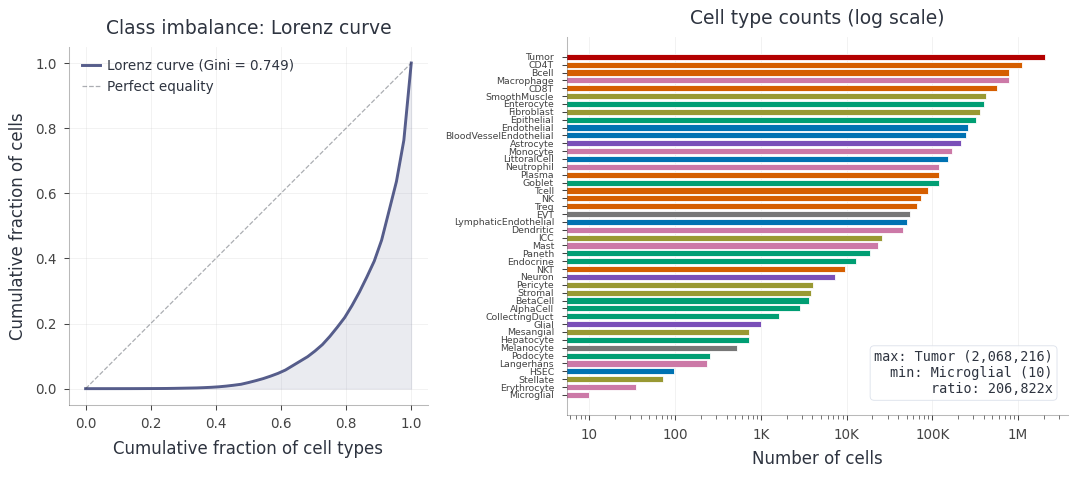

Gini=0.749, max/min ratio=206,822x


In [13]:
sorted_cts9 = sorted(ct_total.keys(), key=lambda x: ct_total[x])
counts9 = np.array([ct_total[c] for c in sorted_cts9], dtype=float)
total9 = counts9.sum()
cumulative = np.insert(np.cumsum(counts9) / total9, 0, 0)
x_frac = np.linspace(0, 1, len(cumulative))
n9 = len(counts9)
gini = (2 * np.sum(np.arange(1, n9 + 1) * counts9) - (n9 + 1) * np.sum(counts9)) \
    / (n9 * np.sum(counts9))

fig, axes = plt.subplots(1, 2, figsize=(COL_2, 3.3), gridspec_kw={'width_ratios': [1, 1.4]})
ax = axes[0]
ax.fill_between(x_frac, cumulative, alpha=0.12, color=PAL['theme'])
ax.plot(x_frac, cumulative, color=PAL['theme'], linewidth=1.4,
        label=f'Lorenz curve (Gini = {gini:.3f})')
ax.plot([0, 1], [0, 1], color=PAL['dark'], linestyle='--', linewidth=0.6, alpha=0.4,
        label='Perfect equality')
ax.set_xlabel('Cumulative fraction of cell types')
ax.set_ylabel('Cumulative fraction of cells')
ax.set_title('Class imbalance: Lorenz curve')
ax.legend(loc='upper left'); ax.set_aspect('equal'); style_ax(ax, grid_axis='both')
ax = axes[1]
cols9 = [LINEAGE_COLORS.get(_get_lineage(c, lineage_map), '#A0A8B4') for c in sorted_cts9]
ax.barh(range(len(sorted_cts9)), counts9, color=cols9, height=BAR_WIDTH, edgecolor='white')
ax.set_yticks(range(len(sorted_cts9))); ax.set_yticklabels(sorted_cts9, fontsize=4.5)
use_log_count_axis(ax, 'x'); ax.set_xlabel('Number of cells')
ax.set_title('Cell type counts (log scale)'); style_ax(ax, grid_axis='x')
ratio = counts9[-1] / max(counts9[0], 1)
ax.text(0.97, 0.05,
        f'max: {sorted_cts9[-1]} ({int(counts9[-1]):,})\n'
        f'min: {sorted_cts9[0]} ({int(counts9[0]):,})\nratio: {ratio:,.0f}x',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=6.5,
        color=PAL['dark'], family='monospace',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=PAL['light_gray'], linewidth=0.4, alpha=0.9))
fig.tight_layout()
plt.show()
print(f'Gini={gini:.3f}, max/min ratio={ratio:,.0f}x')

## 10_celltype_by_modality

_Caption:_ Cell-type breakdown per modality.

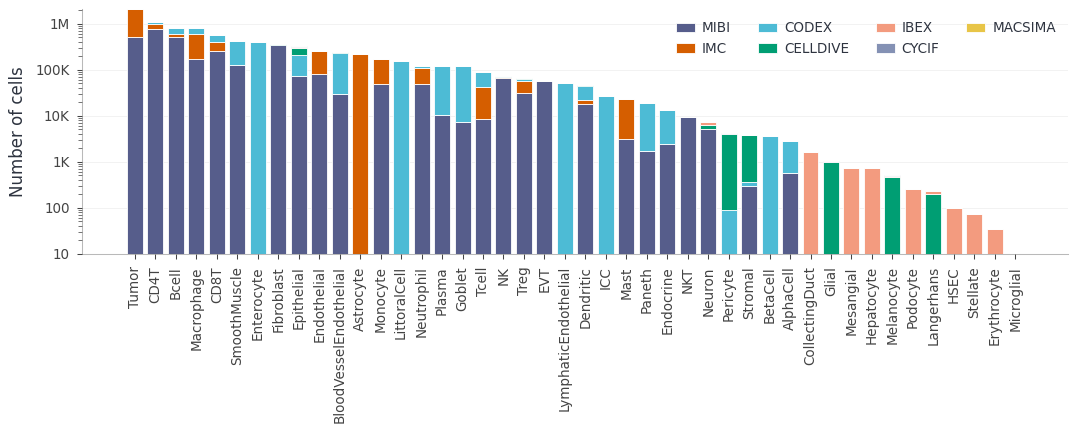

44 types x 7 modalities


In [14]:
ct_mod = defaultdict(Counter)
for r in records:
    for ctn, n in r['ct_counts'].items():
        ct_mod[ctn][r['modality']] += n
sorted_cts10 = sorted(ct_mod, key=lambda x: -sum(ct_mod[x].values()))
modalities10 = sorted(set(m for c in ct_mod.values() for m in c),
                      key=lambda m: -sum(ct_mod[c][m] for c in sorted_cts10))
x = np.arange(len(sorted_cts10))
fig, ax = plt.subplots(figsize=(COL_2, 3.0))
bottom = np.zeros(len(sorted_cts10))
for k, mod_ in enumerate(modalities10):
    vals = np.array([ct_mod[c][mod_] for c in sorted_cts10], dtype=float)
    ax.bar(x, vals, bottom=bottom, label=mod_,
           color=STACKED_COLORS[k % len(STACKED_COLORS)], width=BAR_WIDTH, edgecolor='white')
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(sorted_cts10, rotation=90)
ax.set_ylabel('Number of cells')
ax.legend(ncol=min(len(modalities10), 4), loc='upper right')
use_log_count_axis(ax, 'y'); style_ax(ax, 'y')
fig.tight_layout()
plt.show()
print(f'{len(sorted_cts10)} types x {len(modalities10)} modalities')

## 11_channel_cooccurrence

_Caption:_ Channel co-occurrence (Jaccard similarity across datasets).

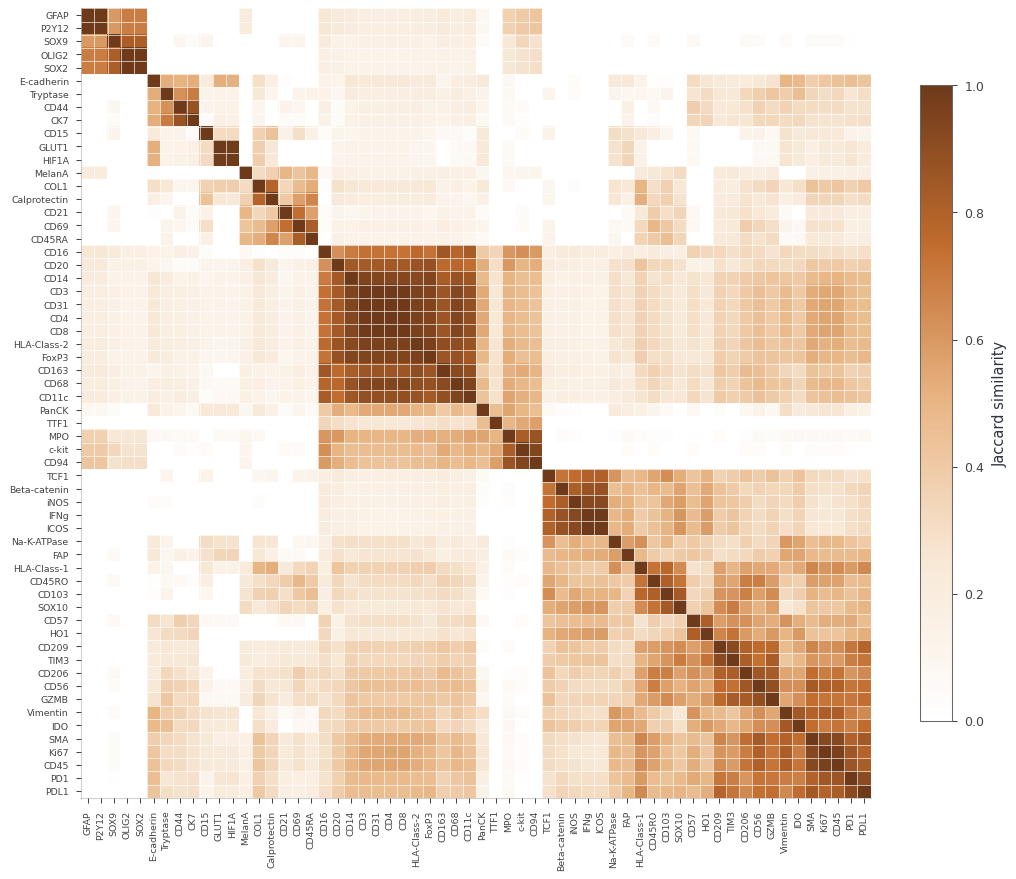

60 x 60 Jaccard matrix


In [15]:
top_n11 = 60
channel_datasets = defaultdict(set)
for i, r in enumerate(records):
    for ch in r['channels']:
        channel_datasets[ch].add(i)
top_channels = sorted(channel_datasets, key=lambda c: -len(channel_datasets[c]))[:top_n11]
n11 = len(top_channels)
sim = np.zeros((n11, n11))
for i in range(n11):
    for j in range(i, n11):
        a, b = channel_datasets[top_channels[i]], channel_datasets[top_channels[j]]
        jac = len(a & b) / max(len(a | b), 1)
        sim[i, j] = sim[j, i] = jac
dist = 1 - sim
np.fill_diagonal(dist, 0)
order = leaves_list(linkage(squareform(dist, checks=False), method='average'))
sim_sorted = sim[order][:, order]
labels_sorted = [top_channels[i] for i in order]

fig, ax = plt.subplots(figsize=(COL_2, COL_2))
im = ax.imshow(sim_sorted, cmap=CMAP_WARM, interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks(range(n11)); ax.set_xticklabels(labels_sorted, rotation=90, fontsize=4.5)
ax.set_yticks(range(n11)); ax.set_yticklabels(labels_sorted, fontsize=4.5)
cb = fig.colorbar(im, ax=ax, shrink=0.6)
cb.set_label('Jaccard similarity', fontsize=7); cb.ax.tick_params(labelsize=6)
ax.set_xticks(np.arange(-0.5, n11, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n11, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.3)
ax.tick_params(which='minor', size=0)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_alpha(0.3)
fig.tight_layout()
plt.show()
print(f'{n11} x {n11} Jaccard matrix')

## 12_channel_stats

_Caption:_ Per-channel statistics (frequency, range, present-in-N-datasets).

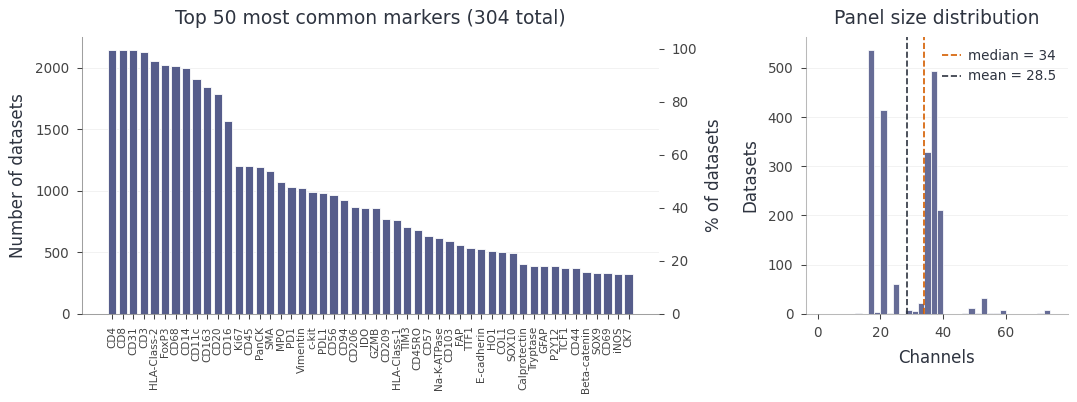

304 unique markers, median panel=34 channels


In [16]:
top_n12 = 50
channel_freq = Counter()
for r in records:
    for ch in r['channels']:
        channel_freq[ch] += 1
n_ds = len(records)
fig, axes = plt.subplots(1, 2, figsize=(COL_2, 2.8), gridspec_kw={'width_ratios': [2.2, 1]})
ax = axes[0]
top_ch = channel_freq.most_common(top_n12)
names12 = [c[0] for c in top_ch]; counts12 = [c[1] for c in top_ch]
ax.bar(range(len(names12)), counts12, color=PAL['theme'], width=BAR_WIDTH, edgecolor='white')
ax.set_xticks(range(len(names12))); ax.set_xticklabels(names12, rotation=90, fontsize=5.0)
ax.set_ylabel('Number of datasets')
ax.set_title(f'Top {top_n12} most common markers ({len(channel_freq)} total)')
ax2 = ax.twinx(); ax2.set_ylim(0, ax.get_ylim()[1] / n_ds * 100)
ax2.set_ylabel('% of datasets'); style_ax(ax, 'y')
for sp in ('top',):
    ax2.spines[sp].set_visible(False)
for sp in ('left', 'right', 'bottom'):
    ax2.spines[sp].set_alpha(0.3)
ax = axes[1]
n_channels = [r['n_channels'] for r in records]
ax.hist(n_channels, bins=range(0, max(n_channels) + 5, 2), color=PAL['theme'],
        edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(np.median(n_channels), color=PAL['red'], linestyle='--', linewidth=0.8,
           label=f'median = {np.median(n_channels):.0f}')
ax.axvline(np.mean(n_channels), color=PAL['dark'], linestyle='--', linewidth=0.8,
           label=f'mean = {np.mean(n_channels):.1f}')
ax.set_xlabel('Channels'); ax.set_ylabel('Datasets')
ax.set_title('Panel size distribution'); ax.legend(loc='upper right'); style_ax(ax, 'y')
fig.tight_layout()
plt.show()
print(f'{len(channel_freq)} unique markers, median panel={np.median(n_channels):.0f} channels')

## 13_modality_marker_coverage

_Caption:_ Fraction of FOVs in each imaging modality that contain each marker
(top 80 markers).

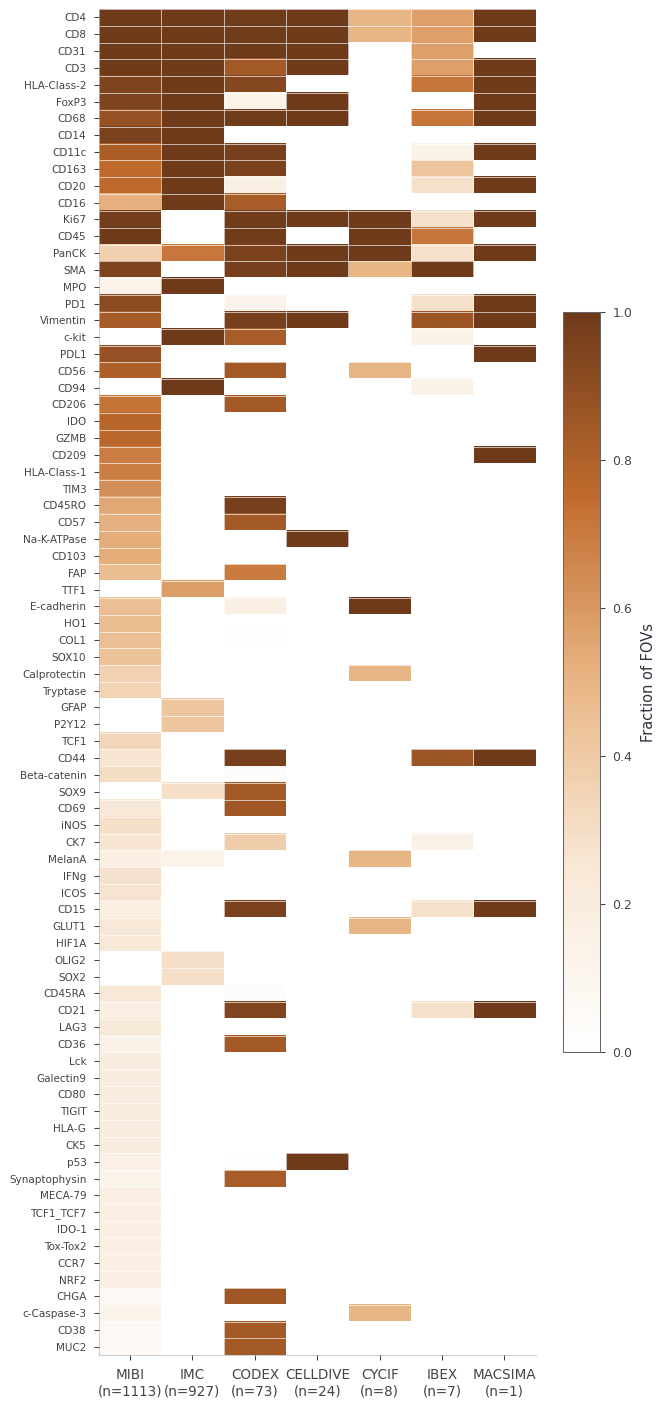

80 markers x 7 modalities


In [17]:
top_n13 = 80
by_mod_fov = Counter()
by_mod_ch = defaultdict(Counter)
total_ch13 = Counter()
for r in records:
    by_mod_fov[r['modality']] += 1
    for ch in set(r['channels']):
        by_mod_ch[r['modality']][ch] += 1
        total_ch13[ch] += 1
modalities13 = sorted(by_mod_fov, key=lambda m: -by_mod_fov[m])
top_markers13 = [c for c, _ in total_ch13.most_common(top_n13)]
mat13 = np.zeros((len(top_markers13), len(modalities13)))
for i, ch in enumerate(top_markers13):
    for j, mod_ in enumerate(modalities13):
        mat13[i, j] = by_mod_ch[mod_][ch] / max(by_mod_fov[mod_], 1)

fig, ax = plt.subplots(figsize=(COL_2 * 0.62, min(MAX_HEIGHT, max(6.0, len(top_markers13) * 0.13))))
im = ax.imshow(mat13, aspect='auto', cmap=CMAP_WARM, vmin=0, vmax=1, interpolation='nearest')
ax.set_yticks(range(len(top_markers13))); ax.set_yticklabels(top_markers13, fontsize=5.0)
ax.set_xticks(range(len(modalities13)))
ax.set_xticklabels([f'{m}\n(n={by_mod_fov[m]})' for m in modalities13],
                   rotation=0, ha='center', fontsize=6.5)
cb = fig.colorbar(im, ax=ax, shrink=0.55)
cb.set_label('Fraction of FOVs', fontsize=7); cb.ax.tick_params(labelsize=6)
ax.set_xticks(np.arange(-0.5, len(modalities13), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(top_markers13), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.3); ax.tick_params(which='minor', size=0)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_alpha(0.3)
fig.tight_layout()
plt.show()
print(f'{len(top_markers13)} markers x {len(modalities13)} modalities')

### Cached per-cell intensity table (panels 14 & 17)

Panels 14 and 17 read the pre-computed long-form per-cell mean-intensity table
(`figures_data/channel_intensity_stats.npz`; columns `marker`, `intensity`,
`cell_type`) so they skip a full archive raw-array rescan.

In [18]:
with np.load(paths.need(paths.FIGURES_DATA / 'channel_intensity_stats.npz'),
             allow_pickle=True) as d:
    intensity_stats = {'marker': d['marker'], 'intensity': d['intensity'],
                       'cell_type': d['cell_type']}
print(f"intensity table: {len(intensity_stats['marker']):,} rows, "
      f"{(intensity_stats['cell_type'] != '').sum():,} with cell-type labels")

intensity table: 594,000 rows, 280,436 with cell-type labels


## 14_marker_intensity_range

_Caption:_ Per-cell mean intensity distributions per marker on the
post-normalization [0, 1] scale, sampled from the archive.

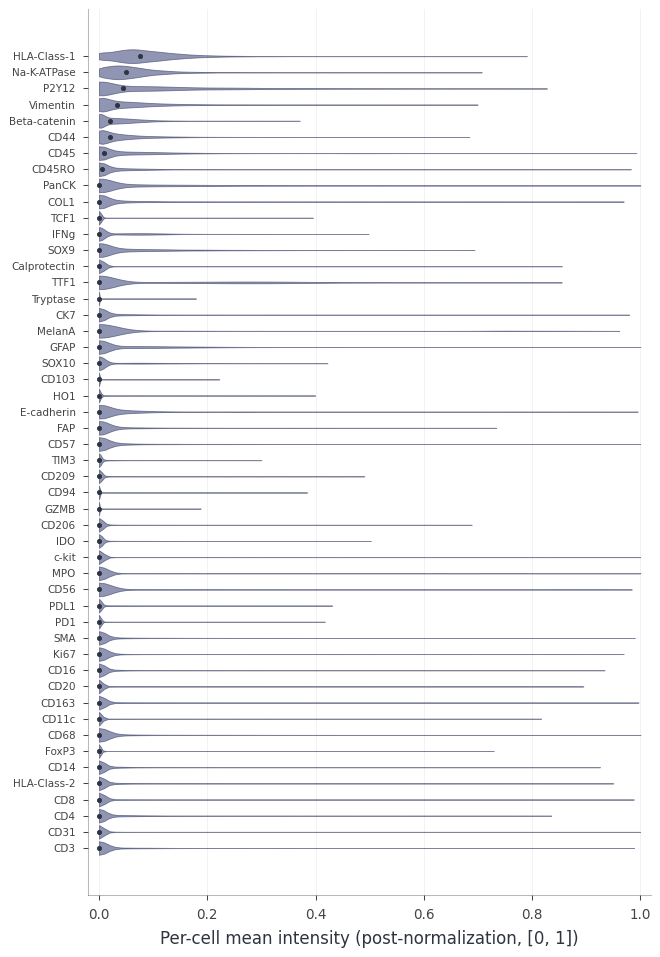

50 markers, 475,600 per-cell points total


In [19]:
top_n14 = 50
markers14 = intensity_stats['marker']; intens14 = intensity_stats['intensity']
order14 = np.argsort(markers14)
sm, si = markers14[order14], intens14[order14]
by_marker = {}
start = 0
while start < len(sm):
    end = start + 1
    while end < len(sm) and sm[end] == sm[start]:
        end += 1
    by_marker[str(sm[start])] = si[start:end]
    start = end
ordered14 = [(n, a) for n, a in sorted(by_marker.items(), key=lambda kv: -len(kv[1]))[:top_n14]
             if a.size > 0]
ordered14.sort(key=lambda kv: float(np.median(kv[1])))
names14 = [n for n, _ in ordered14]; arrs14 = [a for _, a in ordered14]

fig, ax = plt.subplots(figsize=(COL_2 * 0.62, max(4.0, len(names14) * 0.13)))
parts = ax.violinplot(arrs14, vert=False, showextrema=False, widths=0.85)
for body in parts['bodies']:
    body.set_facecolor(PAL['theme']); body.set_alpha(0.65)
    body.set_edgecolor(PAL['theme_dark']); body.set_linewidth(0.4)
meds = [float(np.median(a)) for a in arrs14]
ax.scatter(meds, range(1, len(arrs14) + 1), color=PAL['dark'], s=4, zorder=3)
ax.set_yticks(range(1, len(names14) + 1)); ax.set_yticklabels(names14, fontsize=5.0)
ax.set_xlabel('Per-cell mean intensity (post-normalization, [0, 1])')
ax.set_xlim(-0.02, 1.02); style_ax(ax, grid_axis='x')
fig.tight_layout()
plt.show()
print(f'{len(names14)} markers, {sum(len(a) for a in arrs14):,} per-cell points total')

## 15_marker_celltype_specificity

_Caption:_ Marker x cell-type canonical positivity heatmap; rows ranked by row
entropy (most lineage-specific first).

> Reads canonical `marker_positivity` label matrices from the MP-labelled
> datasets in the archive (one extra zarr-attrs pass over those datasets).

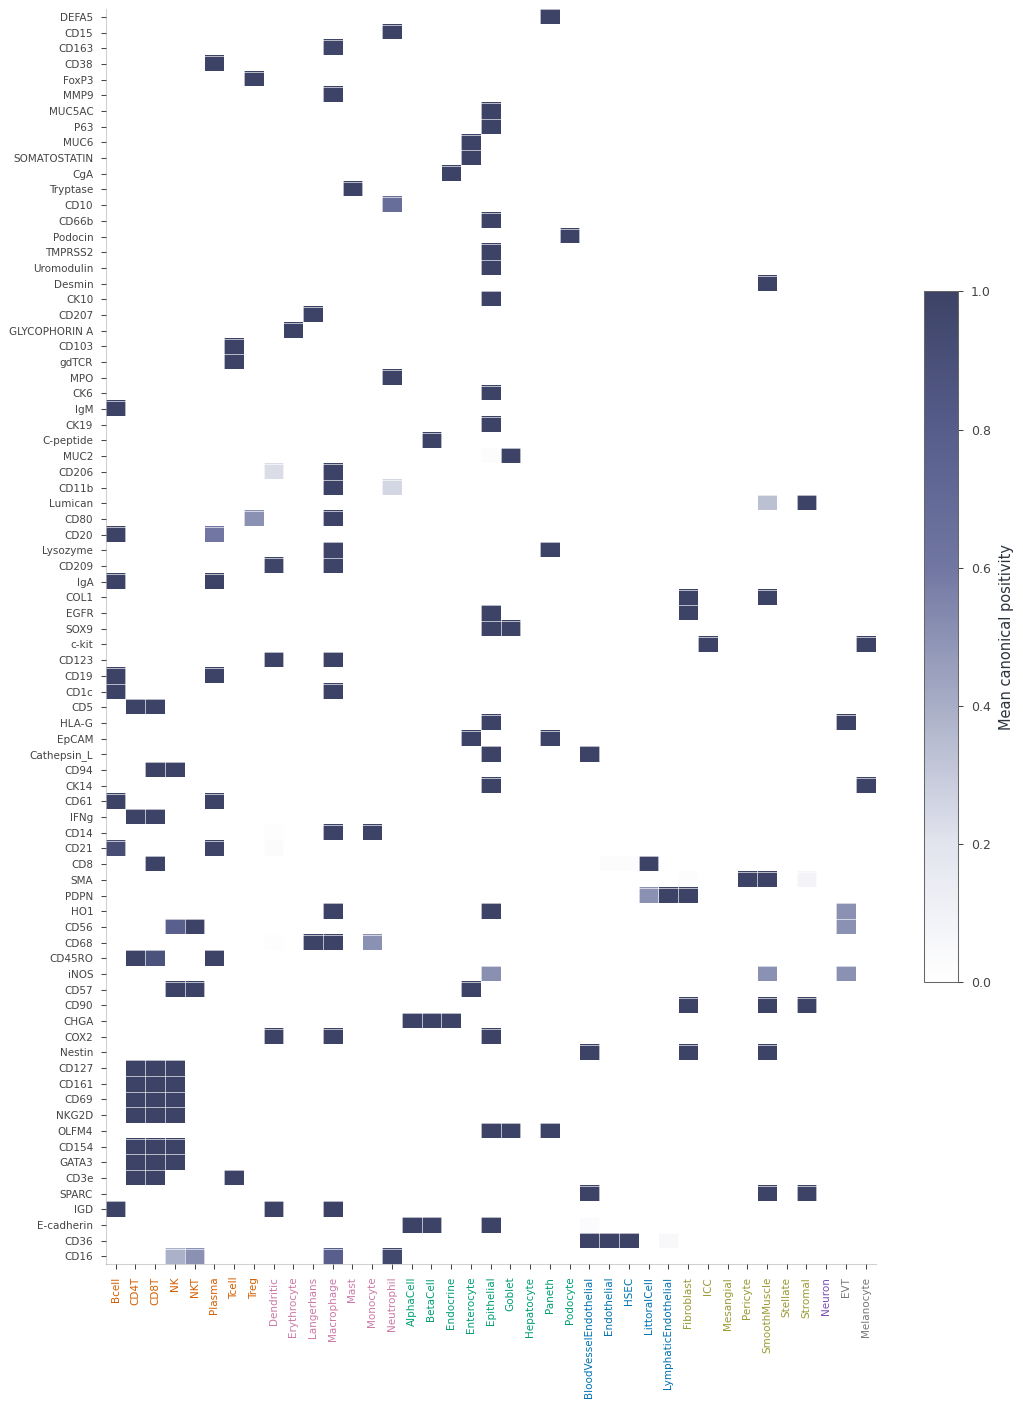

80 markers x 39 cell types


In [20]:
top_n15 = 80
accum = defaultdict(lambda: defaultdict(list))
mp_labels = config.marker_positivity_labels
for key in mp_labels.keys():
    df = mp_labels[key]
    if df is None:
        continue
    for ctn in df.index:
        if ctn not in config.ct2idx:
            continue
        for marker in df.columns:
            v = df.at[ctn, marker]
            if pd.isna(v):
                continue
            accum[marker][ctn].append(float(v))

if not accum:
    print('  [15] no canonical marker_positivity data — skipping')
else:
    cts_present = sorted({c for v in accum.values() for c in v})
    cts_ordered = sorted(cts_present,
                         key=lambda c: (LINEAGE_ORDER.index(lineage_map.get(c, 'Other'))
                                        if lineage_map.get(c, 'Other') in LINEAGE_ORDER else 99, c))
    marker_vecs = {}
    for marker, by_ct in accum.items():
        v = np.zeros(len(cts_ordered), dtype=np.float32)
        for j, ctn in enumerate(cts_ordered):
            vals = by_ct.get(ctn, [])
            if vals:
                v[j] = float(np.mean(vals))
        marker_vecs[marker] = v
    def _entropy(v):
        p = v / max(v.sum(), 1e-9); p = p[p > 0]
        return -float((p * np.log(p)).sum()) if p.size else 0.0
    enriched = sorted([(m, v) for m, v in marker_vecs.items() if v.sum() > 0],
                      key=lambda mv: _entropy(mv[1]))[:top_n15]
    names15 = [m for m, _ in enriched]
    mat15 = np.stack([v for _, v in enriched], axis=0)

    fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(5.0, len(names15) * 0.13))))
    im = ax.imshow(mat15, aspect='auto', cmap=CMAP_BLUES, vmin=0, vmax=1, interpolation='nearest')
    ax.set_yticks(range(len(names15))); ax.set_yticklabels(names15, fontsize=5.0)
    ax.set_xticks(range(len(cts_ordered)))
    ax.set_xticklabels(cts_ordered, rotation=90, fontsize=5.0)
    for i, ctn in enumerate(cts_ordered):
        ax.get_xticklabels()[i].set_color(
            LINEAGE_COLORS.get(lineage_map.get(ctn, 'Other'), PAL['dark']))
    cb = fig.colorbar(im, ax=ax, shrink=0.55)
    cb.set_label('Mean canonical positivity', fontsize=7); cb.ax.tick_params(labelsize=6)
    ax.set_xticks(np.arange(-0.5, len(cts_ordered), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(names15), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=0.3); ax.tick_params(which='minor', size=0)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    for sp in ('left', 'bottom'):
        ax.spines[sp].set_alpha(0.3)
    fig.tight_layout()
    plt.show()
    print(f'{len(names15)} markers x {len(cts_ordered)} cell types')

## 16_marker_embedding_2d

_Caption:_ SVD-reduced marker embedding t-SNE, colored by canonical lineage
(argmax cell-type positivity).

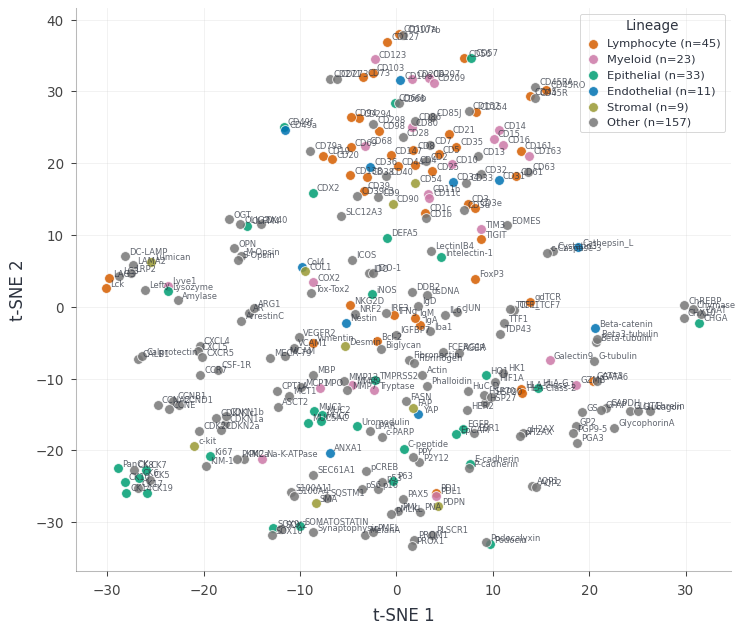

278 markers projected


In [21]:
from sklearn.manifold import TSNE

# Assign each marker its argmax-positivity lineage from the panel-15 accum.
marker_to_lin = {}
for marker, by_ct in accum.items():
    best_ct, best_v = None, 0.0
    for ctn, vals in by_ct.items():
        mv = float(np.mean(vals)) if vals else 0.0
        if mv > best_v:
            best_v, best_ct = mv, ctn
    if best_ct is not None:
        marker_to_lin[marker] = lineage_map.get(best_ct, 'Other')

svd = np.load(paths.need(paths.EMBEDDINGS / 'svd_512.npz'), allow_pickle=True)
emb = svd['marker_embeddings']
m2i = svd['marker2idx']
cand = m2i.item() if hasattr(m2i, 'item') else m2i
if isinstance(cand, (bytes, str)):
    cand = json.loads(cand)
names16 = [None] * len(cand)
for k, vv in cand.items():
    if 0 <= int(vv) < len(names16):
        names16[int(vv)] = str(k)
if any(n is None for n in names16):
    names16 = [f'row{i}' for i in range(emb.shape[0])]

keep = [i for i, n in enumerate(names16) if not n.startswith('row')] or list(range(len(names16)))
emb = emb[keep]; names16 = [names16[i] for i in keep]
nz = np.linalg.norm(emb, axis=1) > 0
emb = emb[nz]; names16 = [n for n, k in zip(names16, nz) if k]

perp = max(5, min(15, (len(names16) - 1) // 3))
xy = TSNE(n_components=2, perplexity=perp, init='pca', learning_rate='auto',
          random_state=0, max_iter=2000).fit_transform(emb)
df16 = pd.DataFrame({'x': xy[:, 0], 'y': xy[:, 1], 'marker': names16,
                     'lineage': [marker_to_lin.get(m, 'Other') for m in names16]})

fig, ax = plt.subplots(figsize=(COL_2 * 0.7, COL_2 * 0.7 * 0.85))
lineages_present = [l for l in LINEAGE_ORDER if l in df16['lineage'].unique()]
leftover16 = sorted(set(df16['lineage'].unique()) - set(LINEAGE_ORDER))
for lin_ in lineages_present + leftover16:
    sub = df16[df16['lineage'] == lin_]
    ax.scatter(sub['x'], sub['y'], s=22, alpha=0.85, edgecolor='white', linewidth=0.4,
               color=LINEAGE_COLORS.get(lin_, '#A0A8B4'), label=f'{lin_} (n={len(sub)})')
for _, row in df16.iterrows():
    ax.annotate(row['marker'], (row['x'], row['y']), fontsize=4.0, alpha=0.75,
                color=PAL['dark'], xytext=(2, 1), textcoords='offset points')
ax.legend(loc='upper right', fontsize=5.5, ncol=1, frameon=True, framealpha=0.9,
          title='Lineage', title_fontsize=6.5)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2'); style_ax(ax, grid_axis='both')
fig.tight_layout()
plt.show()
print(f'{len(df16)} markers projected')

## 17_marker_celltype_auc

_Caption:_ Single-channel intensity AUC for each marker vs one-vs-rest cell
type; rows ranked by max-AUC, columns ordered by lineage. Pairs with panel 15
(label-based) as the intensity-based view of marker discriminability.

/tmp/claude-1011/ipykernel_2195483/3192702502.py:31: RuntimeWarning: All-NaN slice encountered
  row_max = np.nanmax(auc, axis=1)
/tmp/claude-1011/ipykernel_2195483/3192702502.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdBu_r').copy(); cmap.set_bad(color=PAL['light_gray'])


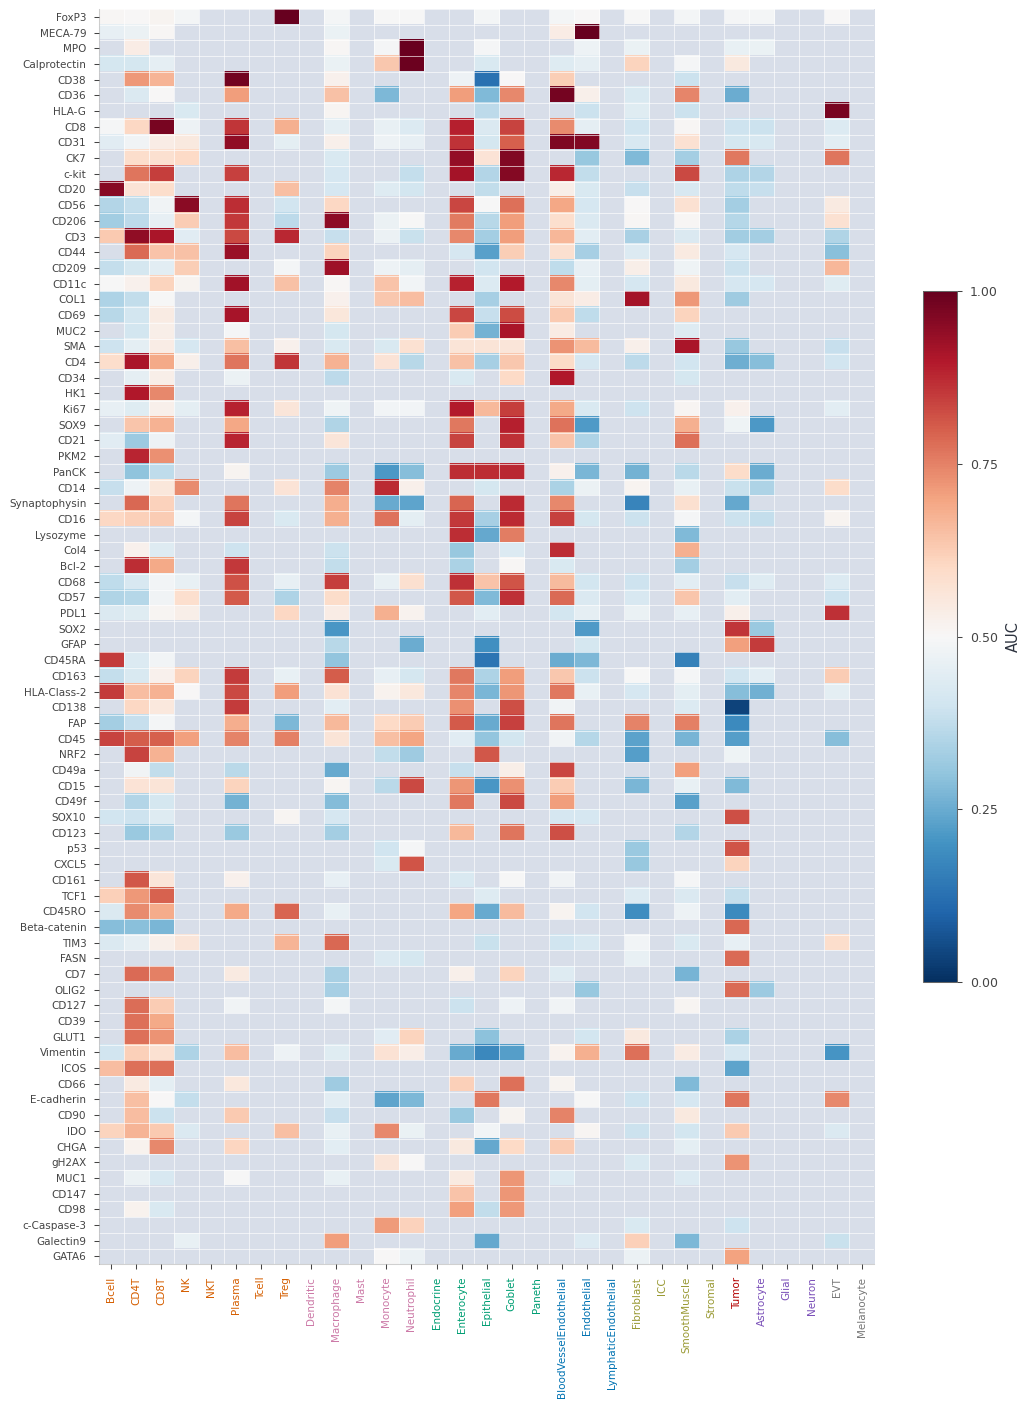

80 markers x 31 cell types, 847 valid pairs (gray = below support floor)


In [22]:
from scipy.stats import rankdata

top_n17, min_pos, min_neg = 80, 30, 200
mk17 = intensity_stats['marker']; it17 = intensity_stats['intensity']
ct17 = intensity_stats['cell_type']
labelled = (ct17 != '') & np.isin(ct17, list(config.ct2idx))
mk17, it17, ct17 = mk17[labelled], it17[labelled], ct17[labelled]

if not labelled.any():
    print('  [17] no labelled per-cell intensity rows — skipping')
else:
    unique_markers = sorted(set(map(str, mk17)))
    unique_cts = sorted(set(map(str, ct17)),
                        key=lambda c: (LINEAGE_ORDER.index(lineage_map.get(c, 'Other'))
                                       if lineage_map.get(c, 'Other') in LINEAGE_ORDER else 99, c))
    auc = np.full((len(unique_markers), len(unique_cts)), np.nan, dtype=np.float32)
    for mi, m in enumerate(unique_markers):
        sel = mk17 == m
        if not sel.any():
            continue
        x_, c_ = it17[sel], ct17[sel]
        ranks = rankdata(x_, method='average'); n_total = x_.size
        for cj, ctn in enumerate(unique_cts):
            pos = c_ == ctn
            n_p = int(pos.sum()); n_n = n_total - n_p
            if n_p < min_pos or n_n < min_neg:
                continue
            u_pos = ranks[pos].sum() - n_p * (n_p + 1) / 2.0
            auc[mi, cj] = u_pos / (n_p * n_n)

    row_max = np.nanmax(auc, axis=1)
    valid_rows = np.isfinite(row_max)
    if not valid_rows.any():
        print(f'  [17] all pairs below support floor (min_pos={min_pos}, '
              f'min_neg={min_neg}) — skipping')
    else:
        order17 = np.argsort(-np.where(valid_rows, row_max, -np.inf))[:min(top_n17, valid_rows.sum())]
        markers_sub = [unique_markers[i] for i in order17]
        auc_sub = auc[order17]
        masked = np.ma.masked_invalid(auc_sub)
        cmap = plt.cm.get_cmap('RdBu_r').copy(); cmap.set_bad(color=PAL['light_gray'])
        fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(5.0, len(markers_sub) * 0.13))))
        im = ax.imshow(masked, aspect='auto', cmap=cmap, vmin=0.0, vmax=1.0, interpolation='nearest')
        ax.set_yticks(range(len(markers_sub))); ax.set_yticklabels(markers_sub, fontsize=5.0)
        ax.set_xticks(range(len(unique_cts)))
        ax.set_xticklabels(unique_cts, rotation=90, fontsize=5.0)
        for i, ctn in enumerate(unique_cts):
            ax.get_xticklabels()[i].set_color(
                LINEAGE_COLORS.get(lineage_map.get(ctn, 'Other'), PAL['dark']))
        cb = fig.colorbar(im, ax=ax, shrink=0.55)
        cb.set_label('AUC', fontsize=7); cb.ax.tick_params(labelsize=6)
        cb.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_xticks(np.arange(-0.5, len(unique_cts), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(markers_sub), 1), minor=True)
        ax.grid(which='minor', color='white', linewidth=0.3); ax.tick_params(which='minor', size=0)
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)
        for sp in ('left', 'bottom'):
            ax.spines[sp].set_alpha(0.3)
        fig.tight_layout()
        plt.show()
        print(f'{len(markers_sub)} markers x {len(unique_cts)} cell types, '
              f'{int(np.isfinite(auc_sub).sum()):,} valid pairs '
              f'(gray = below support floor)')